# Классификация стадии БП — упражнение 'Улыбка'

Три задачи: (1) ранняя vs поздняя стадия БП, (2) ранняя диагностика — здоровые vs ранняя БП, (3) трёхклассовая — здоровые vs ранняя vs поздняя.


Подключаем необходимые библиотеки.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 13
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedGroupKFold, cross_validate
from sklearn.metrics import confusion_matrix, make_scorer, roc_auc_score
from sklearn.feature_selection import SelectKBest, f_classif
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE   = 42
CLINICAL_PATH  = r'/Users/ar_suleymanov/Desktop/Data_diplom/Данные по испытуемым /(v25.05.2024) PD_MDS-UPDRS рабочий.xlsx'
print('Импорты OK')

Импорты OK


## 1. Загрузка данных

Загружаем полный датасет — PD и здоровые. Признаки для всех задач одинаковые.


In [2]:
df_full = pd.read_csv('data_ML_smile_pivot_dinamika_areas.csv')
df_full = df_full.drop(columns=[c for c in ['num_frames','exercise_duration'] if c in df_full.columns])
print(f'Всего: {len(df_full)}, PD: {(df_full["label"]==1).sum()}, HC: {(df_full["label"]==0).sum()}')
feat_cols = [c for c in df_full.columns if c.startswith('dist_')]
print(f'Признаков: {len(feat_cols)}')

Всего: 255, PD: 156, HC: 99
Признаков: 806


## 2. Клинические данные и формирование таргетов

Из Excel загружаем стадии по Хен-Яру для PD-пациентов и формируем три таргета.


In [3]:
df_clin = pd.read_excel(CLINICAL_PATH).set_index('№')

df_pd = df_full[df_full['label'] == 1].copy()
df_pd['patient_num'] = df_pd['id'].str.replace('Patient', '').astype(int)

def clean_stage(x):
    s = str(x).strip()
    if s in ['nan', 'None', 'Атипичный'] or '2024' in s or '->' in s:
        return np.nan
    try: return int(float(s))
    except: return np.nan

df_pd['stage_raw'] = df_pd['patient_num'].map(df_clin['Стадия по Хен-Яру']).apply(clean_stage)
df_pd['target_hy'] = df_pd['stage_raw'].apply(
    lambda x: 0 if x in [1,2] else (1 if x in [3,4] else np.nan))

# Присоединяем стадию к полному датасету
df_full = df_full.merge(df_pd[['id','r','stage_raw','target_hy']], on=['id','r'], how='left')

# Ранняя диагностика: HC(0) vs ранняя стадия БП(1)
df_full['target_early_diag'] = np.nan
df_full.loc[df_full['label'] == 0, 'target_early_diag'] = 0
df_full.loc[df_full['stage_raw'].isin([1,2]), 'target_early_diag'] = 1

# 3 класса: HC(0) vs ранняя(1) vs поздняя(2)
df_full['target_3class'] = np.nan
df_full.loc[df_full['label'] == 0, 'target_3class'] = 0
df_full.loc[df_full['stage_raw'].isin([1,2]), 'target_3class'] = 1
df_full.loc[df_full['stage_raw'].isin([3,4]), 'target_3class'] = 2

hy  = df_full['target_hy'].value_counts().rename({0:'ранняя(1-2)',1:'поздняя(3-4)'})
ed  = df_full['target_early_diag'].value_counts().rename({0.0:'HC',1.0:'ранняя'})
c3  = df_full['target_3class'].value_counts().rename({0.0:'HC',1.0:'ранняя',2.0:'поздняя'})
print(f'Хен-Яр:             ранняя(1-2)={hy.get("ранняя(1-2)",0)}, поздняя(3-4)={hy.get("поздняя(3-4)",0)}')
print(f'Ранняя диагностика: HC={ed.get("HC",0)}, ранняя БП={ed.get("ранняя",0)}')
print(f'3 класса:           HC={c3.get("HC",0)}, ранняя={c3.get("ранняя",0)}, поздняя={c3.get("поздняя",0)}')

Хен-Яр:             ранняя(1-2)=68, поздняя(3-4)=83
Ранняя диагностика: HC=99, ранняя БП=68
3 класса:           HC=99, ранняя=68, поздняя=83


## 3. Инфраструктура ML

Два варианта пайплайна: бинарный (задачи 1 и 2) и мультиклассовый (задача 3). Валидация: StratifiedGroupKFold(5), группировка по id пациента.


In [4]:
class CorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.95):
        self.threshold = threshold
    def fit(self, X, y=None):
        X_df = X if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        corr = X_df.corr().abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        cols = list(upper.columns)
        to_drop = set(c for c in cols if any(upper[c] > self.threshold))
        self.keep_mask_ = np.array([c not in to_drop for c in cols])
        return self
    def transform(self, X):
        return (X.values if isinstance(X, pd.DataFrame) else X)[:, self.keep_mask_]

def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)

scoring_binary = {
    'balanced_accuracy': 'balanced_accuracy',
    'roc_auc':           'roc_auc',
    'f1':                'f1',
    'sensitivity':       'recall',
    'specificity':       make_scorer(specificity_score),
}

def mc_roc_auc(y_true, y_prob):
    return roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')

scoring_mc = {
    'balanced_accuracy': 'balanced_accuracy',
    'roc_auc_ovr': make_scorer(mc_roc_auc, response_method='predict_proba'),
    'f1_macro':    'f1_macro',
}

def build_models_binary(y):
    return {
        'LR':   LogisticRegression(max_iter=5000, class_weight='balanced', random_state=RANDOM_STATE),
        'RF':   RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                       random_state=RANDOM_STATE, n_jobs=-1),
        'XGB':  XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.1,
                              scale_pos_weight=(y==0).sum()/(y==1).sum(),
                              random_state=RANDOM_STATE, eval_metric='logloss'),
        'LGBM': LGBMClassifier(n_estimators=300, max_depth=4, learning_rate=0.1,
                               class_weight='balanced', random_state=RANDOM_STATE, verbose=-1),
        'SVM':  SVC(kernel='rbf', class_weight='balanced', probability=True,
                    random_state=RANDOM_STATE),
    }

def build_models_mc():
    return {
        'LR':   LogisticRegression(max_iter=5000, class_weight='balanced', random_state=RANDOM_STATE),
        'RF':   RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                       random_state=RANDOM_STATE, n_jobs=-1),
        'XGB':  XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.1,
                              random_state=RANDOM_STATE, eval_metric='mlogloss'),
        'LGBM': LGBMClassifier(n_estimators=300, max_depth=4, learning_rate=0.1,
                               class_weight='balanced', random_state=RANDOM_STATE, verbose=-1),
        'SVM':  SVC(kernel='rbf', class_weight='balanced', probability=True,
                    random_state=RANDOM_STATE),
    }

def run_all(X, y, groups, k_select=None):
    cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    res = {}
    for name, model in build_models_binary(y).items():
        steps = [('corr', CorrelationFilter(0.95)), ('scaler', StandardScaler())]
        if k_select is not None:
            steps.append(('select', SelectKBest(f_classif, k=min(k_select, X.shape[1]))))
        steps.append(('model', model))
        pipe = Pipeline(steps)
        cvr = cross_validate(pipe, X, y, groups=groups, cv=cv,
                             scoring=scoring_binary, return_train_score=False)
        res[name] = {k: (np.mean(cvr[f'test_{k}']), np.std(cvr[f'test_{k}'])) for k in scoring_binary}
    return res

def run_all_mc(X, y, groups):
    cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    res = {}
    for name, model in build_models_mc().items():
        pipe = Pipeline([
            ('corr',   CorrelationFilter(0.95)),
            ('scaler', StandardScaler()),
            ('model',  model),
        ])
        cvr = cross_validate(pipe, X, y, groups=groups, cv=cv,
                             scoring=scoring_mc, return_train_score=False)
        res[name] = {k: (np.mean(cvr[f'test_{k}']), np.std(cvr[f'test_{k}'])) for k in scoring_mc}
    return res

model_names   = ['LR', 'RF', 'XGB', 'LGBM', 'SVM']
metrics_list  = ['balanced_accuracy', 'roc_auc', 'f1', 'sensitivity', 'specificity']
metric_labels = ['Bal.Acc', 'ROC-AUC', 'F1', 'Sensitivity', 'Specificity']
print('Функции определены.')

Функции определены.


In [5]:
def show_results(res, title):
    rows = []
    for mn in model_names:
        r = res[mn]
        rows.append({'Model': mn,
            'ROC-AUC':  f'{r["roc_auc"][0]:.3f}±{r["roc_auc"][1]:.3f}',
            'Bal.Acc':  f'{r["balanced_accuracy"][0]:.3f}±{r["balanced_accuracy"][1]:.3f}',
            'F1':       f'{r["f1"][0]:.3f}±{r["f1"][1]:.3f}',
            'Sens':     f'{r["sensitivity"][0]:.3f}',
            'Spec':     f'{r["specificity"][0]:.3f}',
        })
    print(f'\n── {title} ──')
    display(pd.DataFrame(rows).set_index('Model'))
    hm = np.array([[res[mn][met][0] for met in metrics_list] for mn in model_names])
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.heatmap(hm, xticklabels=metric_labels, yticklabels=model_names,
                annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.4, vmax=0.9, ax=ax)
    ax.set_title(title); plt.tight_layout(); plt.show()

def show_results_mc(res, title):
    rows = []
    for mn in model_names:
        r = res[mn]
        rows.append({'Model': mn,
            'ROC-AUC (OvR)': f'{r["roc_auc_ovr"][0]:.3f}±{r["roc_auc_ovr"][1]:.3f}',
            'Bal.Acc':       f'{r["balanced_accuracy"][0]:.3f}±{r["balanced_accuracy"][1]:.3f}',
            'F1 (macro)':    f'{r["f1_macro"][0]:.3f}±{r["f1_macro"][1]:.3f}',
        })
    print(f'\n── {title} ──')
    display(pd.DataFrame(rows).set_index('Model'))
    mc_metrics = ['balanced_accuracy', 'roc_auc_ovr', 'f1_macro']
    mc_labels  = ['Bal.Acc', 'ROC-AUC OvR', 'F1 macro']
    hm = np.array([[res[mn][met][0] for met in mc_metrics] for mn in model_names])
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.heatmap(hm, xticklabels=mc_labels, yticklabels=model_names,
                annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.4, vmax=0.9, ax=ax)
    ax.set_title(title); plt.tight_layout(); plt.show()

print('OK')

OK


## 4. Ранняя диагностика: Здоровые vs Ранняя стадия (1–2)

Бинарная классификация: норма против ранней формы БП.


Наблюдений: 167, уникальных пациентов: 77
  HC (0):        99 наблюдений, 27 пациентов
  Ранняя БП (1): 68 наблюдений, 50 пациентов

── Ранняя диагностика: HC vs ранняя стадия (1-2) ──


,ROC-AUC,Bal.Acc,F1,Sens,Spec
Model,,,,,
LR,0.736±0.085,0.670±0.076,0.642±0.128,0.710,0.629
RF,0.846±0.040,0.758±0.066,0.713±0.092,0.713,0.803
XGB,0.868±0.046,0.767±0.048,0.732±0.106,0.750,0.783
LGBM,0.869±0.030,0.737±0.050,0.695±0.128,0.732,0.742
SVM,0.814±0.044,0.748±0.046,0.714±0.075,0.804,0.691


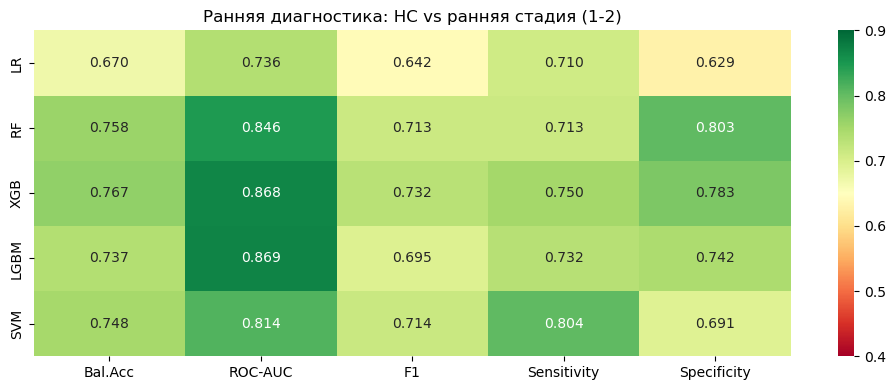


═══ ИТОГ ═══  LGBM: AUC=0.869


In [6]:
# HC + PD с ранней стадией (1-2)
df_early = df_full[df_full['target_early_diag'].notna()].copy()
y_early  = df_early['target_early_diag'].astype(int)
grp_e    = df_early['id']
X_early  = df_early[feat_cols]

print(f'Наблюдений: {len(df_early)}, уникальных пациентов: {grp_e.nunique()}')
print(f'  HC (0):        {(y_early==0).sum()} наблюдений, {df_early[y_early==0]["id"].nunique()} пациентов')
print(f'  Ранняя БП (1): {(y_early==1).sum()} наблюдений, {df_early[y_early==1]["id"].nunique()} пациентов')

res_early = run_all(X_early, y_early, grp_e)
show_results(res_early, 'Ранняя диагностика: HC vs ранняя стадия (1-2)')
best_model_early = max(model_names, key=lambda m: res_early[m]['roc_auc'][0])
print(f'\n═══ ИТОГ ═══  {best_model_early}: AUC={res_early[best_model_early]["roc_auc"][0]:.3f}')

## 5. Трёхклассовая: Здоровые vs Ранняя (1–2) vs Поздняя (3–4)

Мультиклассовая задача. Метрика — ROC-AUC One-vs-Rest (macro).


Наблюдений: 250, уникальных пациентов: 146
  HC (0):        99 наблюдений, 27 пациентов
  Ранняя (1):    68 наблюдений, 50 пациентов
  Поздняя (2):   83 наблюдений, 69 пациентов

── Стадии: HC vs ранняя (1-2) vs поздняя (3-4) ──


,ROC-AUC (OvR),Bal.Acc,F1 (macro)
Model,,,
LR,0.687±0.042,0.517±0.063,0.507±0.073
RF,0.742±0.041,0.536±0.036,0.521±0.045
XGB,0.725±0.048,0.535±0.044,0.529±0.052
LGBM,0.714±0.057,0.496±0.042,0.489±0.040
SVM,0.747±0.035,0.561±0.031,0.543±0.034


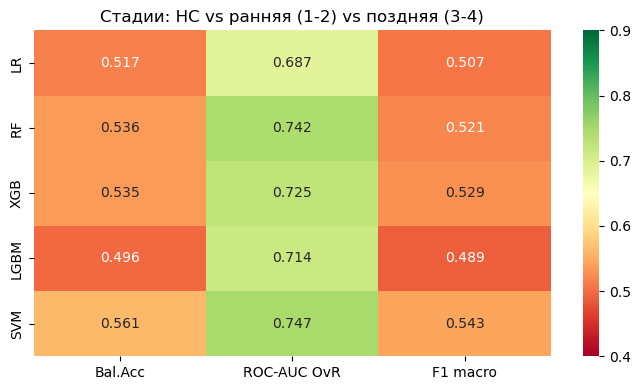


═══ ИТОГ ═══  SVM: ROC-AUC OvR=0.747


In [7]:
# HC + PD с ранней (1-2) и поздней (3-4) стадией
df_3c = df_full[df_full['target_3class'].notna()].copy()
y_3c  = df_3c['target_3class'].astype(int)
grp_3 = df_3c['id']
X_3c  = df_3c[feat_cols]

print(f'Наблюдений: {len(df_3c)}, уникальных пациентов: {grp_3.nunique()}')
print(f'  HC (0):        {(y_3c==0).sum()} наблюдений, {df_3c[y_3c==0]["id"].nunique()} пациентов')
print(f'  Ранняя (1):    {(y_3c==1).sum()} наблюдений, {df_3c[y_3c==1]["id"].nunique()} пациентов')
print(f'  Поздняя (2):   {(y_3c==2).sum()} наблюдений, {df_3c[y_3c==2]["id"].nunique()} пациентов')

res_3c = run_all_mc(X_3c, y_3c, grp_3)
show_results_mc(res_3c, 'Стадии: HC vs ранняя (1-2) vs поздняя (3-4)')
best_model_3c = max(model_names, key=lambda m: res_3c[m]['roc_auc_ovr'][0])
print(f'\n═══ ИТОГ ═══  {best_model_3c}: ROC-AUC OvR={res_3c[best_model_3c]["roc_auc_ovr"][0]:.3f}')

## 6. Ранняя (1–2) vs Поздняя (3–4) стадия

Классификация внутри группы БП. Sweep по числу признаков.


Наблюдений: 151, уникальных пациентов: 119
  Ранняя (1-2): 68 наблюдений, 50 пациентов
  Поздняя (3-4): 83 наблюдений, 69 пациентов
Обучаю (k=20)... лучший AUC=0.611
Обучаю (k=50)... лучший AUC=0.651
Обучаю (k=100)... лучший AUC=0.680
Обучаю (без отбора)... лучший AUC=0.693

Лучший вариант: без отбора

── Хен-Яр: ранняя vs поздняя (без отбора) ──


,ROC-AUC,Bal.Acc,F1,Sens,Spec
Model,,,,,
LR,0.583±0.190,0.566±0.087,0.624±0.101,0.648,0.484
RF,0.693±0.086,0.639±0.111,0.696±0.103,0.745,0.534
XGB,0.609±0.121,0.570±0.082,0.615±0.069,0.629,0.511
LGBM,0.652±0.113,0.631±0.081,0.673±0.074,0.683,0.579
SVM,0.684±0.109,0.642±0.081,0.662±0.105,0.664,0.619


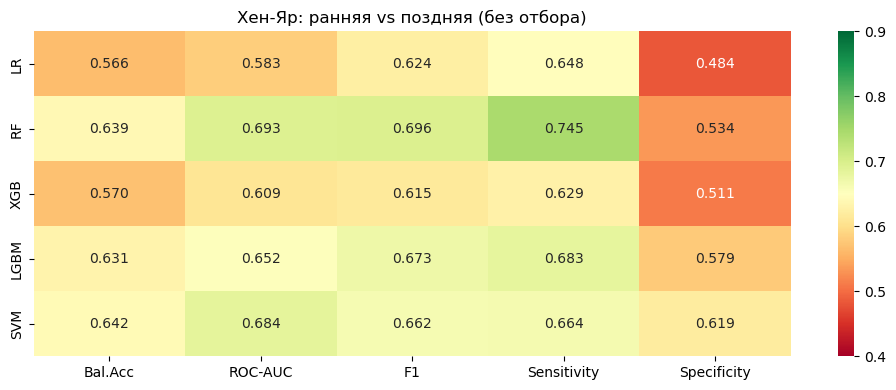


Сравнение вариантов отбора:


,Лучшая модель,ROC-AUC
Отбор признаков,,
k=20,SVM,0.611±0.089
k=50,SVM,0.651±0.090
k=100,RF,0.680±0.089
без отбора,RF,0.693±0.086



═══ ИТОГ ═══  RF: AUC=0.693


In [8]:
# Только PD-пациенты с известной стадией
df_stage = df_full[df_full['target_hy'].notna()].copy()
y_stage  = df_stage['target_hy'].astype(int)
grp      = df_stage['id']
X_stage  = df_stage[feat_cols]

print(f'Наблюдений: {len(df_stage)}, уникальных пациентов: {grp.nunique()}')
print(f'  Ранняя (1-2): {(y_stage==0).sum()} наблюдений, {df_stage[y_stage==0]["id"].nunique()} пациентов')
print(f'  Поздняя (3-4): {(y_stage==1).sum()} наблюдений, {df_stage[y_stage==1]["id"].nunique()} пациентов')

k_values = [20, 50, 100, None]
sweep = {}
for k in k_values:
    label = f'k={k}' if k else 'без отбора'
    print(f'Обучаю ({label})...', end=' ', flush=True)
    sweep[label] = run_all(X_stage, y_stage, grp, k_select=k)
    print(f'лучший AUC={max(sweep[label][m]["roc_auc"][0] for m in model_names):.3f}')

best_label = max(sweep, key=lambda l: sweep[l]['LGBM']['roc_auc'][0])
res_hy = sweep[best_label]
print(f'\nЛучший вариант: {best_label}')
show_results(res_hy, f'Хен-Яр: ранняя vs поздняя ({best_label})')

rows = []
for label, res in sweep.items():
    best_m = max(model_names, key=lambda m: res[m]['roc_auc'][0])
    rows.append({'Отбор признаков': label, 'Лучшая модель': best_m,
                 'ROC-AUC': f'{res[best_m]["roc_auc"][0]:.3f}±{res[best_m]["roc_auc"][1]:.3f}'})
print('\nСравнение вариантов отбора:')
display(pd.DataFrame(rows).set_index('Отбор признаков'))
best_model_hy = max(model_names, key=lambda m: res_hy[m]['roc_auc'][0])
print(f'\n═══ ИТОГ ═══  {best_model_hy}: AUC={res_hy[best_model_hy]["roc_auc"][0]:.3f}')

## Вывод

Запустите ячейки выше для получения результатов.
